In [1]:
def car(env):
    while True:
        print('Start parking at %d' % env.now)
        parking_duration = 5
        yield env.timeout(parking_duration)

        print('Start driving at %d' % env.now)
        trip_duration = 2
        yield env.timeout(trip_duration)

In [2]:
import simpy
env = simpy.Environment()
env.process(car(env))
env.run(until=15)

Start parking at 0
Start driving at 5
Start parking at 7
Start driving at 12
Start parking at 14


In [6]:
import numpy as np
from simpy_helpers import Entity, Resource, Source, Stats
import simpy

## Here is the Entity Subclass
class Call(Entity):
    def process(self):
        yield self.wait_for_resource(call_center)
        yield self.process_at_resource(call_center)
        self.release_resource(call_center)

# Here is the Resource subclass
class CallCenter(Resource):
    def service_time(self, entity):
        problem_size = entity.attributes["problem_size"]
        if problem_size == "sm":
            return 1
        elif problem_size == "md":
            return 3
        else:  # size must be lg at this point
            return 10

# Here is the Source subclass
class CallSource(Source):
    def interarrival_time(self):
        return 1 # every 1 minute, call should arrive to the simulation
    
    def build_entity(self):
        # choose problem_size for this entity based on distribution in scenario.
        problem_size = np.random.choice(["sm", "md", "lg"], p=[0.5, 0.35, 0.15])
        attributes = {
            "problem_size": problem_size
        }
        return Call(env, attributes) # create a call with the chosen problem_size

# Now construct instances of Resource and Source.
np.random.seed(42) # set seed so random parts remain constant between simulations

env = simpy.Environment()
call_center = CallCenter(env, capacity=2) # configure 2 employee capacity
call_source = CallSource(env, number=20) # source will stop after 20 customers have been generated

env.process(call_source.start(debug=True)) # if you want to see printed output for simulation, set debug=True
env.run()

Debug is Enabled
Call 1 created_at: 1 attributes: {'problem_size': np.str_('sm'), 'priority': 1, 'disposed': False, 'type': <class '__main__.Call'>}
Call 1 requesting CallCenter: 1
Call 1 started processing at CallCenter : 1
Call 2 created_at: 2 attributes: {'problem_size': np.str_('lg'), 'priority': 1, 'disposed': False, 'type': <class '__main__.Call'>}
Call 2 requesting CallCenter: 2
Call 1 finished at CallCenter: 2
Call 2 started processing at CallCenter : 2
Call 1 disposed: 2
Call 3 created_at: 3 attributes: {'problem_size': np.str_('md'), 'priority': 1, 'disposed': False, 'type': <class '__main__.Call'>}
Call 3 requesting CallCenter: 3
Call 3 started processing at CallCenter : 3
Call 4 created_at: 4 attributes: {'problem_size': np.str_('md'), 'priority': 1, 'disposed': False, 'type': <class '__main__.Call'>}
Call 4 requesting CallCenter: 4
Call 5 created_at: 5 attributes: {'problem_size': np.str_('sm'), 'priority': 1, 'disposed': False, 'type': <class '__main__.Call'>}
Call 5 requ

In [7]:
system_time = Stats.get_total_times()
print("total_time:", Stats.get_total_times())
print("total waiting_time:", Stats.get_waiting_times()) 
print("total processing_time:", Stats.get_processing_times(), "\n")

print("waiting time for call_center resource", Stats.get_waiting_times(call_center))
print("processing time for call_center resource", Stats.get_processing_times(call_center))
print("total time at call_center resource", Stats.get_total_times(call_center), "\n")

print("call_center queue size over time", Stats.queue_size_over_time(call_center))
print("call_cetner utilization over time", Stats.utilization_over_time(call_center))

print("entities that were not disposed", Stats.get_total_times(attributes={"disposed": False}))

total_time: [1, 10, 3, 5, 5, 5, 5, 14, 6, 8, 8, 17, 12, 12, 12, 12, 12, 14, 11, 11]
total waiting_time: [0, 0, 0, 2, 4, 4, 4, 4, 3, 5, 7, 7, 9, 11, 11, 11, 11, 11, 10, 10]
total processing_time: [1, 10, 3, 3, 1, 1, 1, 10, 3, 3, 1, 10, 3, 1, 1, 1, 1, 3, 1, 1] 

waiting time for call_center resource [0, 0, 0, 2, 4, 4, 4, 4, 3, 5, 7, 7, 9, 11, 11, 11, 11, 11, 10, 10]
processing time for call_center resource [1, 10, 3, 3, 1, 1, 1, 10, 3, 3, 1, 10, 3, 1, 1, 1, 1, 3, 1, 1]
total time at call_center resource [1, 10, 3, 5, 5, 5, 5, 14, 6, 8, 8, 17, 12, 12, 12, 12, 12, 14, 11, 11] 

call_center queue size over time [0, 0, 0, 0, 1, 2, 2, 3, 4, 4, 4, 4, 3, 4, 5, 5, 6, 7, 7, 7, 8, 8, 7, 7, 7, 6, 5, 4, 3, 1, 0, 0, 0]
call_cetner utilization over time [0, np.float64(0.5), np.float64(0.5), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64

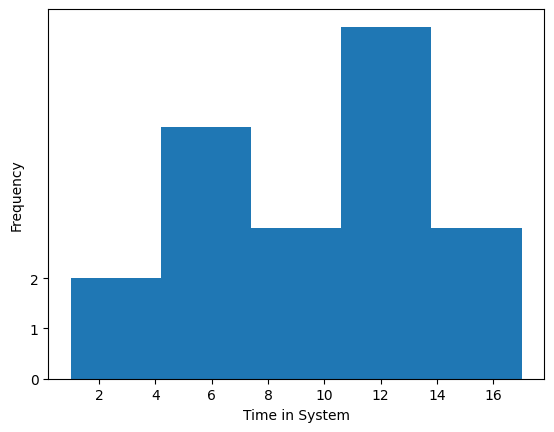

In [8]:
# we can use the return values from these statistics methods to create charts about our simulation's performance
import matplotlib.pyplot as plt

plt.hist(system_time,bins=5)
# you can customize the exact tick marks on an axis
plt.yticks(range(0,3))
plt.ylabel('Frequency');
plt.xlabel('Time in System');